In [20]:
import random
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import warnings

# *Hierarchical Risk Parity* Topológico: Eliminando el Ruido con Árboles de Expansión Mínima
**Maestría en Finanzas Cuantitativas | Universidad del Rosario (2026-II)**

### Abstract
La optimización media-varianza suele fallar en las pruebas fuera de la muestra de entrenamiento debido a la poca estabilidad de la matriz de covarianzas histórica y la amplifiación de los errores de estimación en el tiempo. Los acercamientos modernos que utilizan organización jerarquica, como *Hierarchical Risk Parity* (HRP), atacan este problema utilizando teoría de grafos y agrupamiento (*clustering*) con técnicas de aprendizaje de maquinas para distribuir el riesgo sin la necesidad de invertir matrices. Sin embargo, en momentos de crisis sistémica, las matrices de correlación se vuelven altamente colineales, lo cual introduce ruido al proceso de agrupamiento.

El presente projecto introduce un **Filtro Topológico utilizando Árboles de Expansión Minima (MST)** antes de realizar la distribución jerárquica. Al reducir conexiones redundantes entre activos en nuestro grafo inicial, mantenemos únicamente las conexiones más relevantes para determinar una medida de distancia con mucho menos ruido. El proyecto compara tres estrategias de distribución fuera de la muestra de entrenamiento:

1. Pesos Iguales ($1/N$)
2. Hierarchical Risk Parity Estándar (HRP)
3. MST-Filtered HRP (Nuestra contribución topológica)

### Step 0: Obtener la data
Tomamos los precios de cierre de 40 de los 100 activos que componen el índice S&P 100 de manera aleatoria. La información cubre desde el primero de enero de 2018 hasta el primero de septiembre de 2026. Hacemos énfasis en la inclusión de la pandemia y de la inestabilidad general que la sucede, como periodos temporales de alta volatilidad y ruido en los mercados.

In [21]:
# 1. Universe of S&P 100 components
sp100_tickers = [
    "AAPL", "ABBV", "ABT", "ACN", "ADBE", "AIG", "AMD", "AMGN", "AMT", "AMZN",
    "AVGO", "AXP", "BA", "BAC", "BKNG", "BLK", "BMY", "C", "CAT",
    "CHTR", "CL", "CMCSA", "COF", "COP", "COST", "CRM", "CSCO", "CVS", "CVX",
    "DE", "DHR", "DIS", "DOW", "DUK", "EMR", "FDX", "GD", "GE", "GILD",
    "GM", "GOOGL", "GS", "HD", "HON", "IBM", "INTC", "INTU", "ISRG", "JNJ",
    "JPM", "KHC", "KO", "LIN", "LLY", "LMT", "LOW", "MA", "MCD", "MDLZ",
    "MDT", "MET", "META", "MMM", "MO", "MRK", "MS", "MSFT", "NEE", "NFLX",
    "NKE", "NVDA", "ORCL", "PEP", "PFE", "PG", "PM", "PYPL", "QCOM", "RTX",
    "SBUX", "SCHW", "SO", "SPGI", "T", "TGT", "TJX", "TMO", "TMUS", "TXN",
    "UNH", "UNP", "UPS", "USB", "V", "VZ", "WFC", "WMT", "XOM"
]

# 2. Sample 40 tickers randomly
RANDOM_SEED = 40
random.seed(RANDOM_SEED)
selected_tickers = sorted(random.sample(sp100_tickers, 40))

# 3. Download split and dividend-adjusted close prices
START_DATE = "2018-01-01"
END_DATE = "2026-09-01"

raw_data = yf.download(
    tickers=selected_tickers,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=True
)

prices = raw_data["Close"].copy()

# 4. Filter missing data and fill trading gaps
valid_columns = prices.dropna(thresh=int(len(prices) * 0.95), axis=1)
prices = valid_columns.ffill().bfill()

# Ensure exactly 40 liquid tickers if any had excessive missing values
if prices.shape[1] < 40:
    remaining_pool = [t for t in sp100_tickers if t not in prices.columns]
    needed = 40 - prices.shape[1]
    replacement = random.sample(remaining_pool, needed)
    rep_data = yf.download(replacement, start=START_DATE, end=END_DATE, auto_adjust=True)["Close"]
    prices = pd.concat([prices, rep_data], axis=1).ffill().bfill()
    prices = prices.iloc[:, :40]

# Ensure the index is formatted cleanly as YYYY-MM-DD
prices.index.name = "Date"
prices.index = pd.to_datetime(prices.index).strftime("%Y-%m-%d")

# 5. Export clean dataset to CSV
output_filename = "sp40_historical_prices.csv"
prices.to_csv(output_filename, index=True)

print(f"Dataset successfully saved to '{output_filename}'.")
print(f"Dimensions: {prices.shape[0]} trading days across {prices.shape[1]} equities.")

[*********************100%***********************]  40 of 40 completed
[*********************100%***********************]  1 of 1 completed


Dataset successfully saved to 'sp40_historical_prices.csv'.
Dimensions: 2177 trading days across 40 equities.


### 1. Inicialización y Carga de la data

En esta sección, imporamos los precios históricos necesatios para nuestro análisis. Se calculan los log-retornos diarios para tener composición continua y mejores propiedades estadísticas (mayor normalidad que retornos discretos).

Para un análisis estadístico inicial, utilizamos la muestra completa en la matriz de correlación empírica. Más adelante se implementa una ventana móvil para determinar la viabilidad de las estratégias en un escenario más realista.

In [22]:
# ==========================================
# CELL 1: SETUP & DATA INGESTION
# ==========================================

# Configure visualization settings for academic poster quality
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 300, 'font.size': 12}) # High resolution for Zenodo/Poster

# 1. Load the dataset (Ensure 'sp40_historical_prices.csv' is in the directory)
file_path = "sp40_historical_prices.csv"
prices = pd.read_csv(file_path, index_col=0, parse_dates=True)
print(f"Data ingested: {prices.shape[0]} trading days across {prices.shape[1]} equities.")

# 2. Compute continuous log returns
log_returns = np.log(prices / prices.shift(1)).dropna()

# 3. Compute full-sample covariance and correlation for static topology visualization
cov_matrix = log_returns.cov() * 252
corr_matrix = log_returns.corr()

Data ingested: 2177 trading days across 40 equities.


### 2. Filtro Topólico con Grafos (Minimum Spanning Tree)

Las matrices de correlación financiera son densas y altamente colineales. Para aislar la estructura subyacente real del mercado, se utiliza una matriz de distancia utilizando la siguiente métrica: $D_{i,j} = \sqrt{2(1 - \rho_{i,j})}$.

Tratamos al mercado como una red no dirigida donde los activos son nodos y las aristas son la distancia $D$ entre nodoa. Aplicando el algoritmo de Kruskal, extraemos el **Árbol de Expansión Mínima (MST)**. De esta forma, eliminamos correlaciones ruidosas o transitorias y utilizamos solo los caminos más críticos y robustos entre los activos.

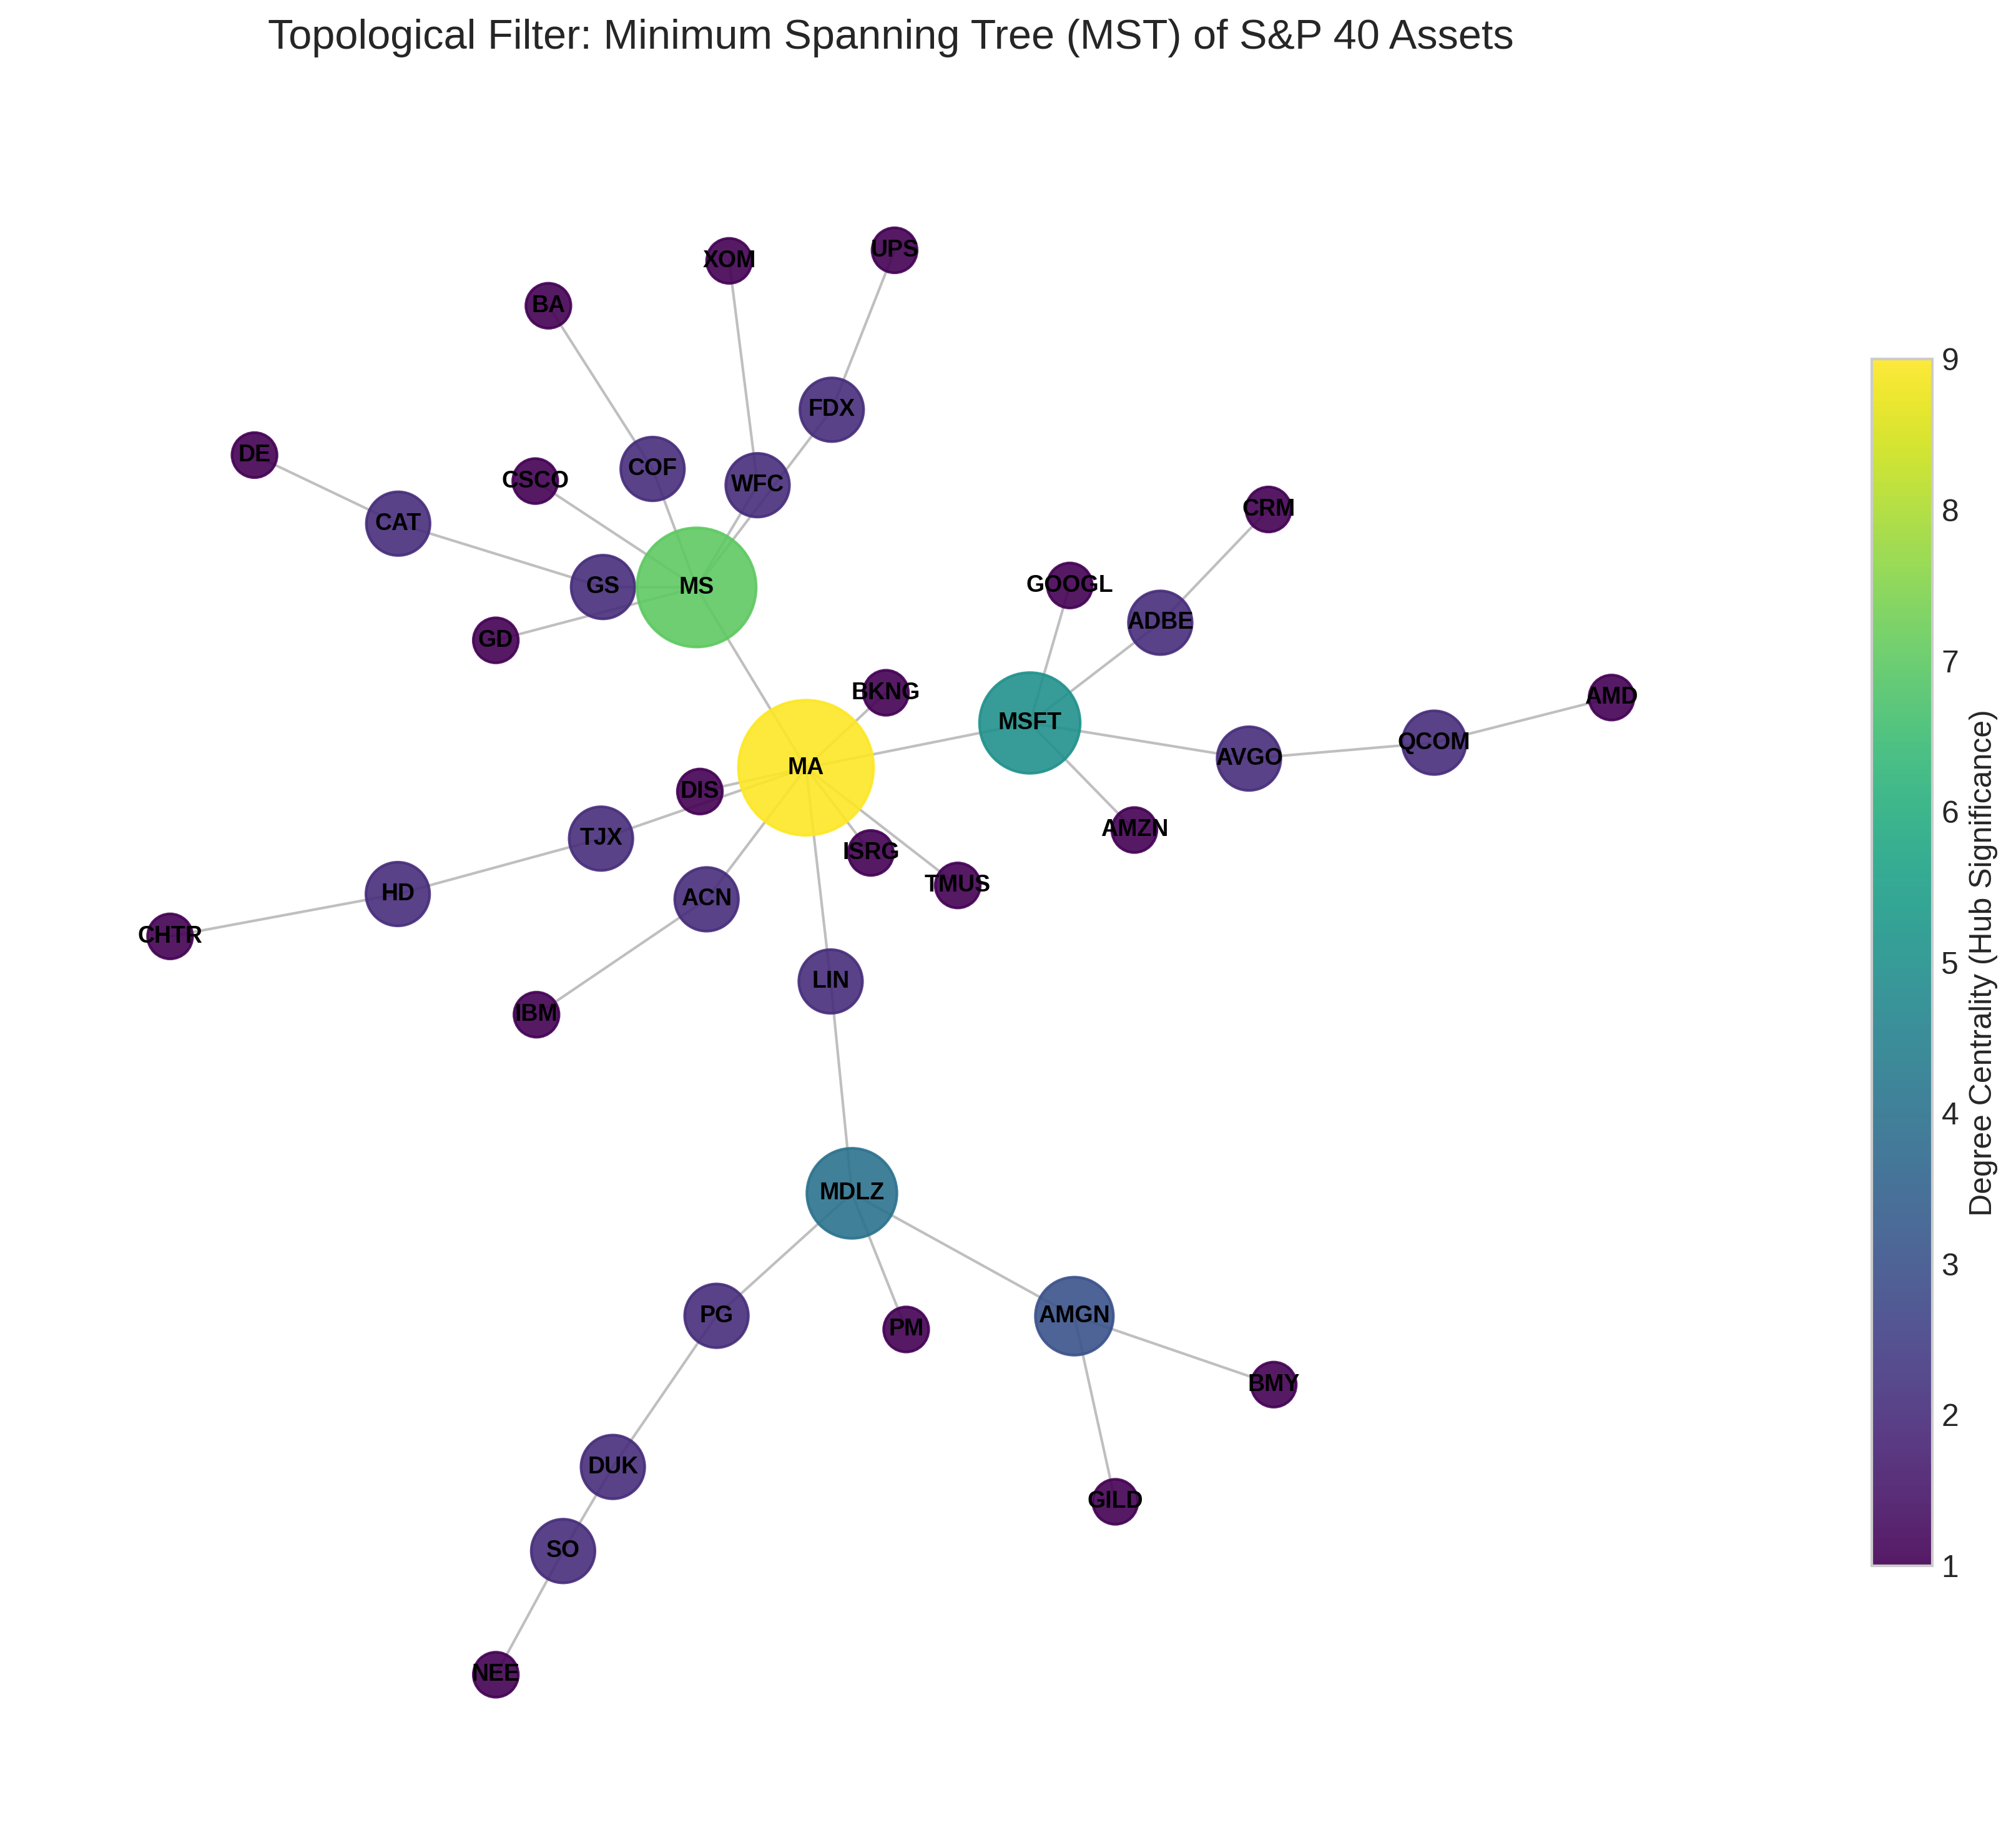

In [23]:
# ==========================================
# CELL 2: MINIMUM SPANNING TREE (MST) FILTER
# ==========================================

def compute_distance_matrix(corr):
    """Converts a Pearson correlation matrix into a mathematical distance matrix."""
    corr_bounded = np.clip(corr, -1.0, 1.0) # Prevent float precision errors outside [-1, 1]
    return np.sqrt(2.0 * (1.0 - corr_bounded))

def extract_mst_distances(dist_matrix, tickers):
    """Constructs a network graph and extracts the Minimum Spanning Tree (MST)."""
    G = nx.Graph()
    # Populate the dense graph with all pairwise distances
    for i in range(len(tickers)):
        for j in range(i + 1, len(tickers)):
            G.add_edge(tickers[i], tickers[j], weight=dist_matrix.iloc[i, j])

    # Prune network down to the MST (N-1 edges)
    mst = nx.minimum_spanning_tree(G, weight='weight')

    # Recalculate pairwise distances strictly along the MST paths
    mst_paths = dict(nx.all_pairs_dijkstra_path_length(mst))
    mst_dist_matrix = pd.DataFrame(index=tickers, columns=tickers, dtype=float)
    for i in tickers:
        for j in tickers:
            mst_dist_matrix.loc[i, j] = mst_paths[i][j]

    return mst_dist_matrix, mst

# Execute the topological filter
raw_dist = compute_distance_matrix(corr_matrix)
mst_dist, mst_graph = extract_mst_distances(raw_dist, log_returns.columns)

# --- POSTER VISUALIZATION 1: MARKET TOPOLOGY ---
plt.figure(figsize=(12, 10))
# Calculate node degree (number of connections) to size and color central hubs
degrees = dict(mst_graph.degree())
node_sizes = [v * 300 for v in degrees.values()]
node_colors = list(degrees.values())

pos = nx.kamada_kawai_layout(mst_graph) # Creates a clean, force-directed layout
nodes = nx.draw_networkx_nodes(mst_graph, pos, node_size=node_sizes,
                               node_color=node_colors, cmap=plt.cm.viridis, alpha=0.9)
nx.draw_networkx_edges(mst_graph, pos, alpha=0.5, edge_color='gray')
nx.draw_networkx_labels(mst_graph, pos, font_size=9, font_weight='bold', font_color='black')

plt.title("Topological Filter: Minimum Spanning Tree (MST) of S&P 40 Assets", fontsize=16, pad=20)
plt.colorbar(nodes, label="Degree Centrality (Hub Significance)", shrink=0.7)
plt.axis('off')
plt.tight_layout()
plt.show()

### 3. Agruopación Jerárquica y Cuasi-Diagonalización

Utilizando las distancias reducidas con MST, applicamos el agrupamiento jerárquico aglomerativo usual de HRP (aplicando *linkage* de Ward).

Esto resulta en un dendograma el cual muestra el orden jerárquico de los activos. Al ordenar la matrix de correlación original de acuerdo a esta estructura de árbol (el proceso conocido como Cuasi-Diagonalización), forzamos a que los grupos altamente correlacionados estén cerca en la diagonal de la matriz. Esto muestra gráficamente cómo la estructura de MST se traduce en clusters de riesgo invertibles diferentes para realizar una diversificación efectiva.

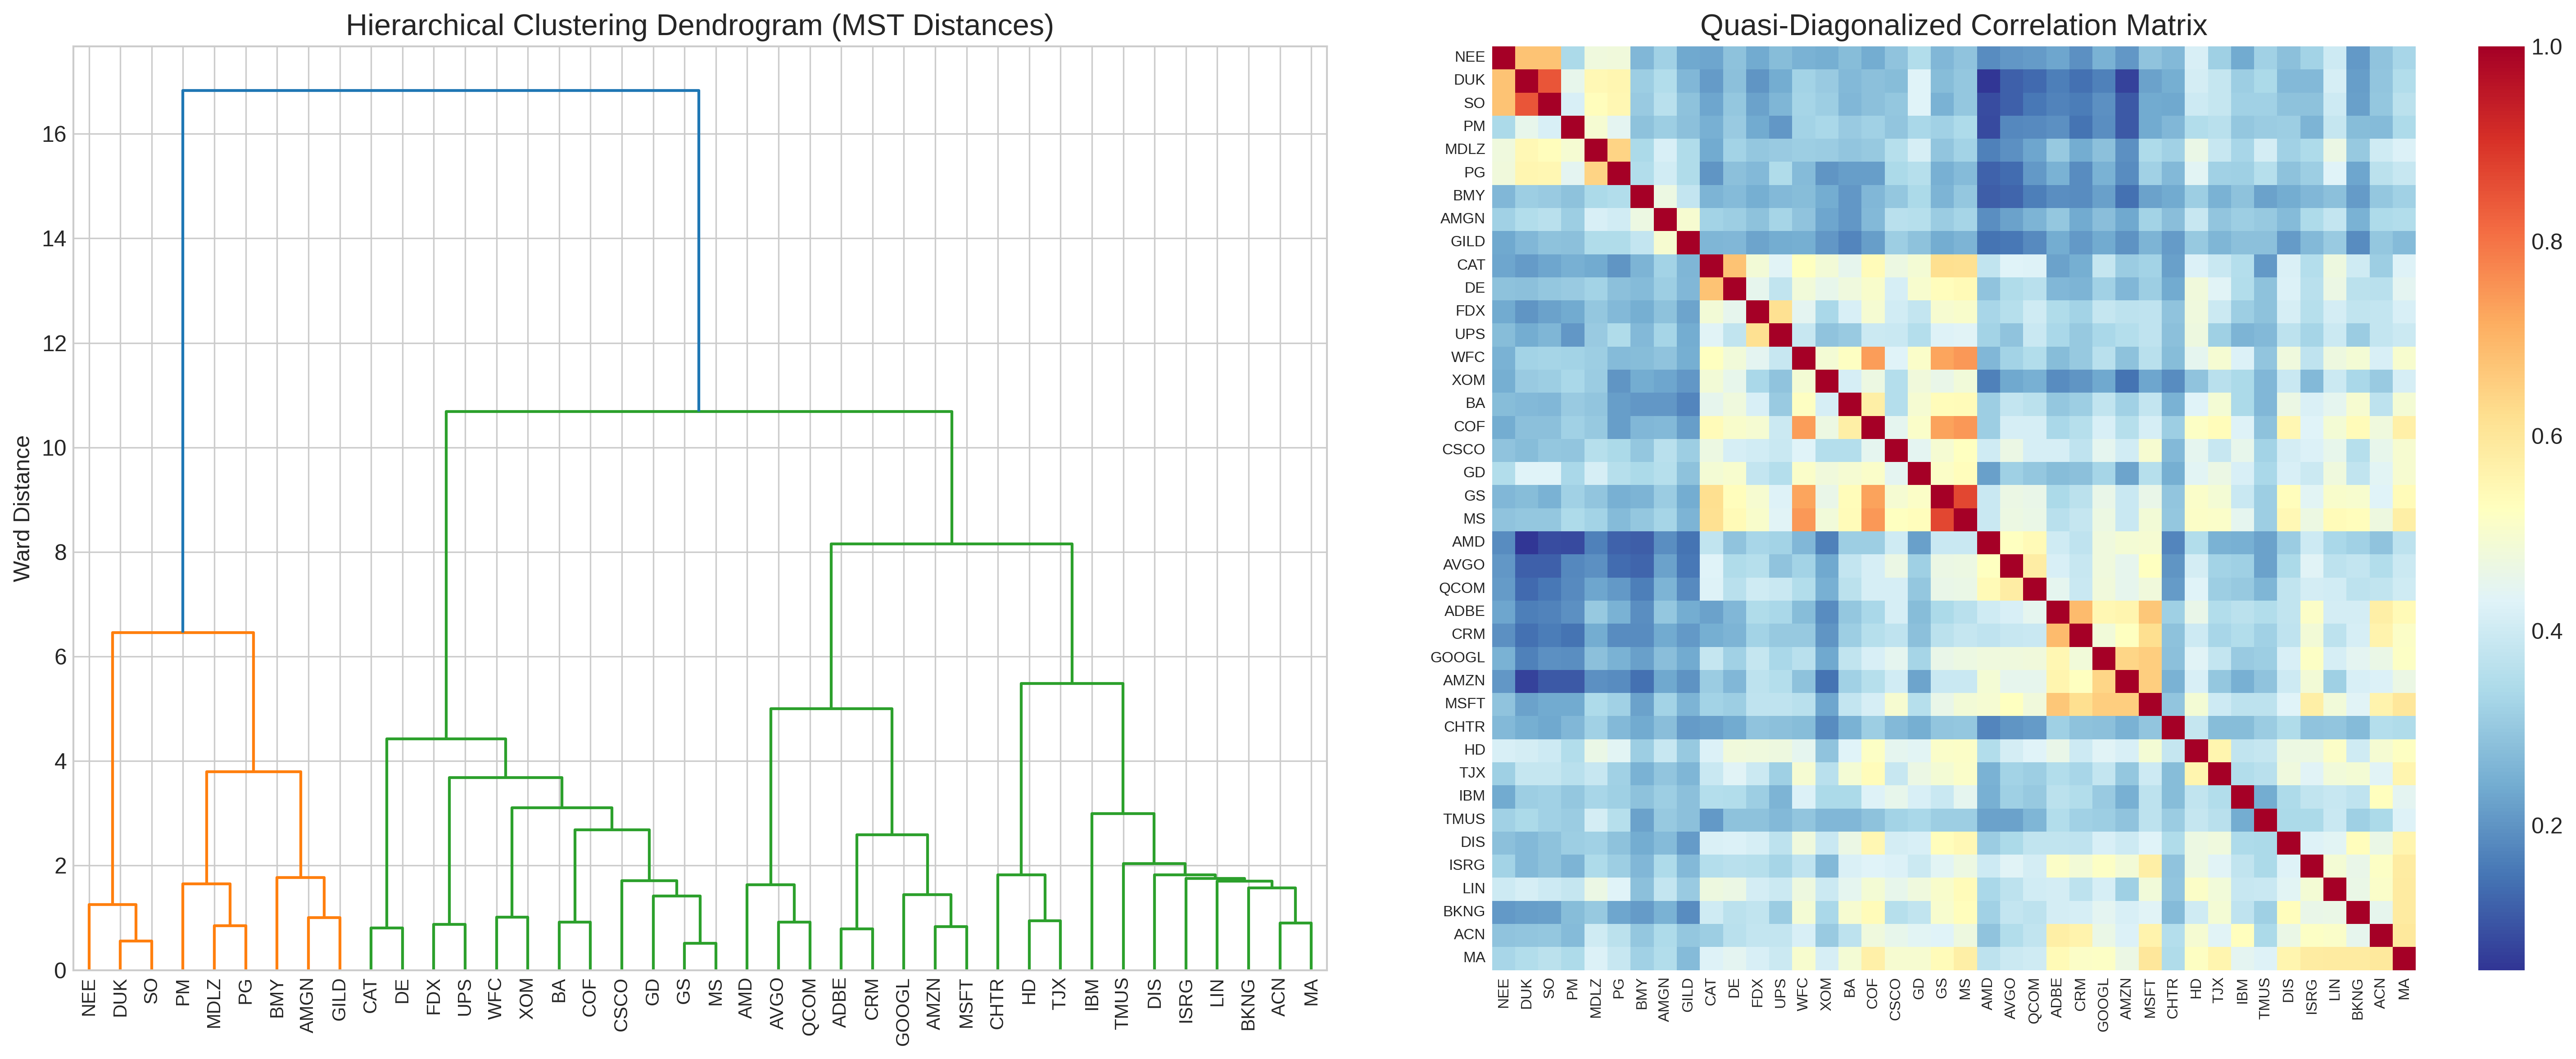

In [24]:
# ==========================================
# CELL 3: HIERARCHICAL CLUSTERING & HEATMAPS
# ==========================================

def get_quasi_diag(link):
    """Sorts assets so that highly correlated items are placed adjacently."""
    link = link.astype(int)
    sort_ix = pd.Series([link[-1, 0], link[-1, 1]])
    num_items = link[-1, 3]

    while sort_ix.max() >= num_items:
        sort_ix.index = range(0, sort_ix.shape[0] * 2, 2)
        df0 = sort_ix[sort_ix >= num_items]
        i = df0.index
        j = df0.values - num_items
        sort_ix[i] = link[j, 0]
        df1 = pd.Series(link[j, 1], index=i+1)
        sort_ix = pd.concat([sort_ix, df1]).sort_index()
        sort_ix.index = range(sort_ix.shape[0])
    return sort_ix.tolist()

# 1. Compute Linkage on the MST distances
condensed_dist = squareform(mst_dist, checks=False)
linkage_matrix = linkage(condensed_dist, method='ward')

# 2. Reorder covariance/correlation matrix (Quasi-Diagonalization)
sorted_indices = get_quasi_diag(linkage_matrix)
tickers_sorted = log_returns.columns[sorted_indices]

# --- POSTER VISUALIZATION 2 & 3: DENDROGRAM AND HEATMAP ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Dendrogram
dendrogram(linkage_matrix, labels=log_returns.columns, ax=ax1, leaf_rotation=90,
           color_threshold=max(linkage_matrix[:, 2]) * 0.7)
ax1.set_title("Hierarchical Clustering Dendrogram (MST Distances)", fontsize=16)
ax1.set_ylabel("Ward Distance", fontsize=12)
ax1.tick_params(axis='x', labelsize=10)

# Quasi-Diagonalized Heatmap
sns.heatmap(corr_matrix.loc[tickers_sorted, tickers_sorted], cmap='RdYlBu_r',
            ax=ax2, cbar=True, square=True, xticklabels=True, yticklabels=True)
ax2.set_title("Quasi-Diagonalized Correlation Matrix", fontsize=16)
ax2.tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.show()

### 4. Bisección Recursiva (Asignación de Riesgo)

Una vez tenemos los grupos de activos dados por el dendograma, aplicamos el paso final: Bisección Recursiva.

Comenzando en la raíz del árbol, el algoritmo divide el capital disponible entre la rama izquierda y la rama derecha. La asignación se realiza dando un peso inversamente proporcional a la varianza de cada rama. Al distribuir el riesgo entre las ramas del árbol sin ruido, HRP evita los problemas de invertir la matriz de correlación y reduce la posibilidad de asignar demasiado peso a factores de riesgo redundantes.

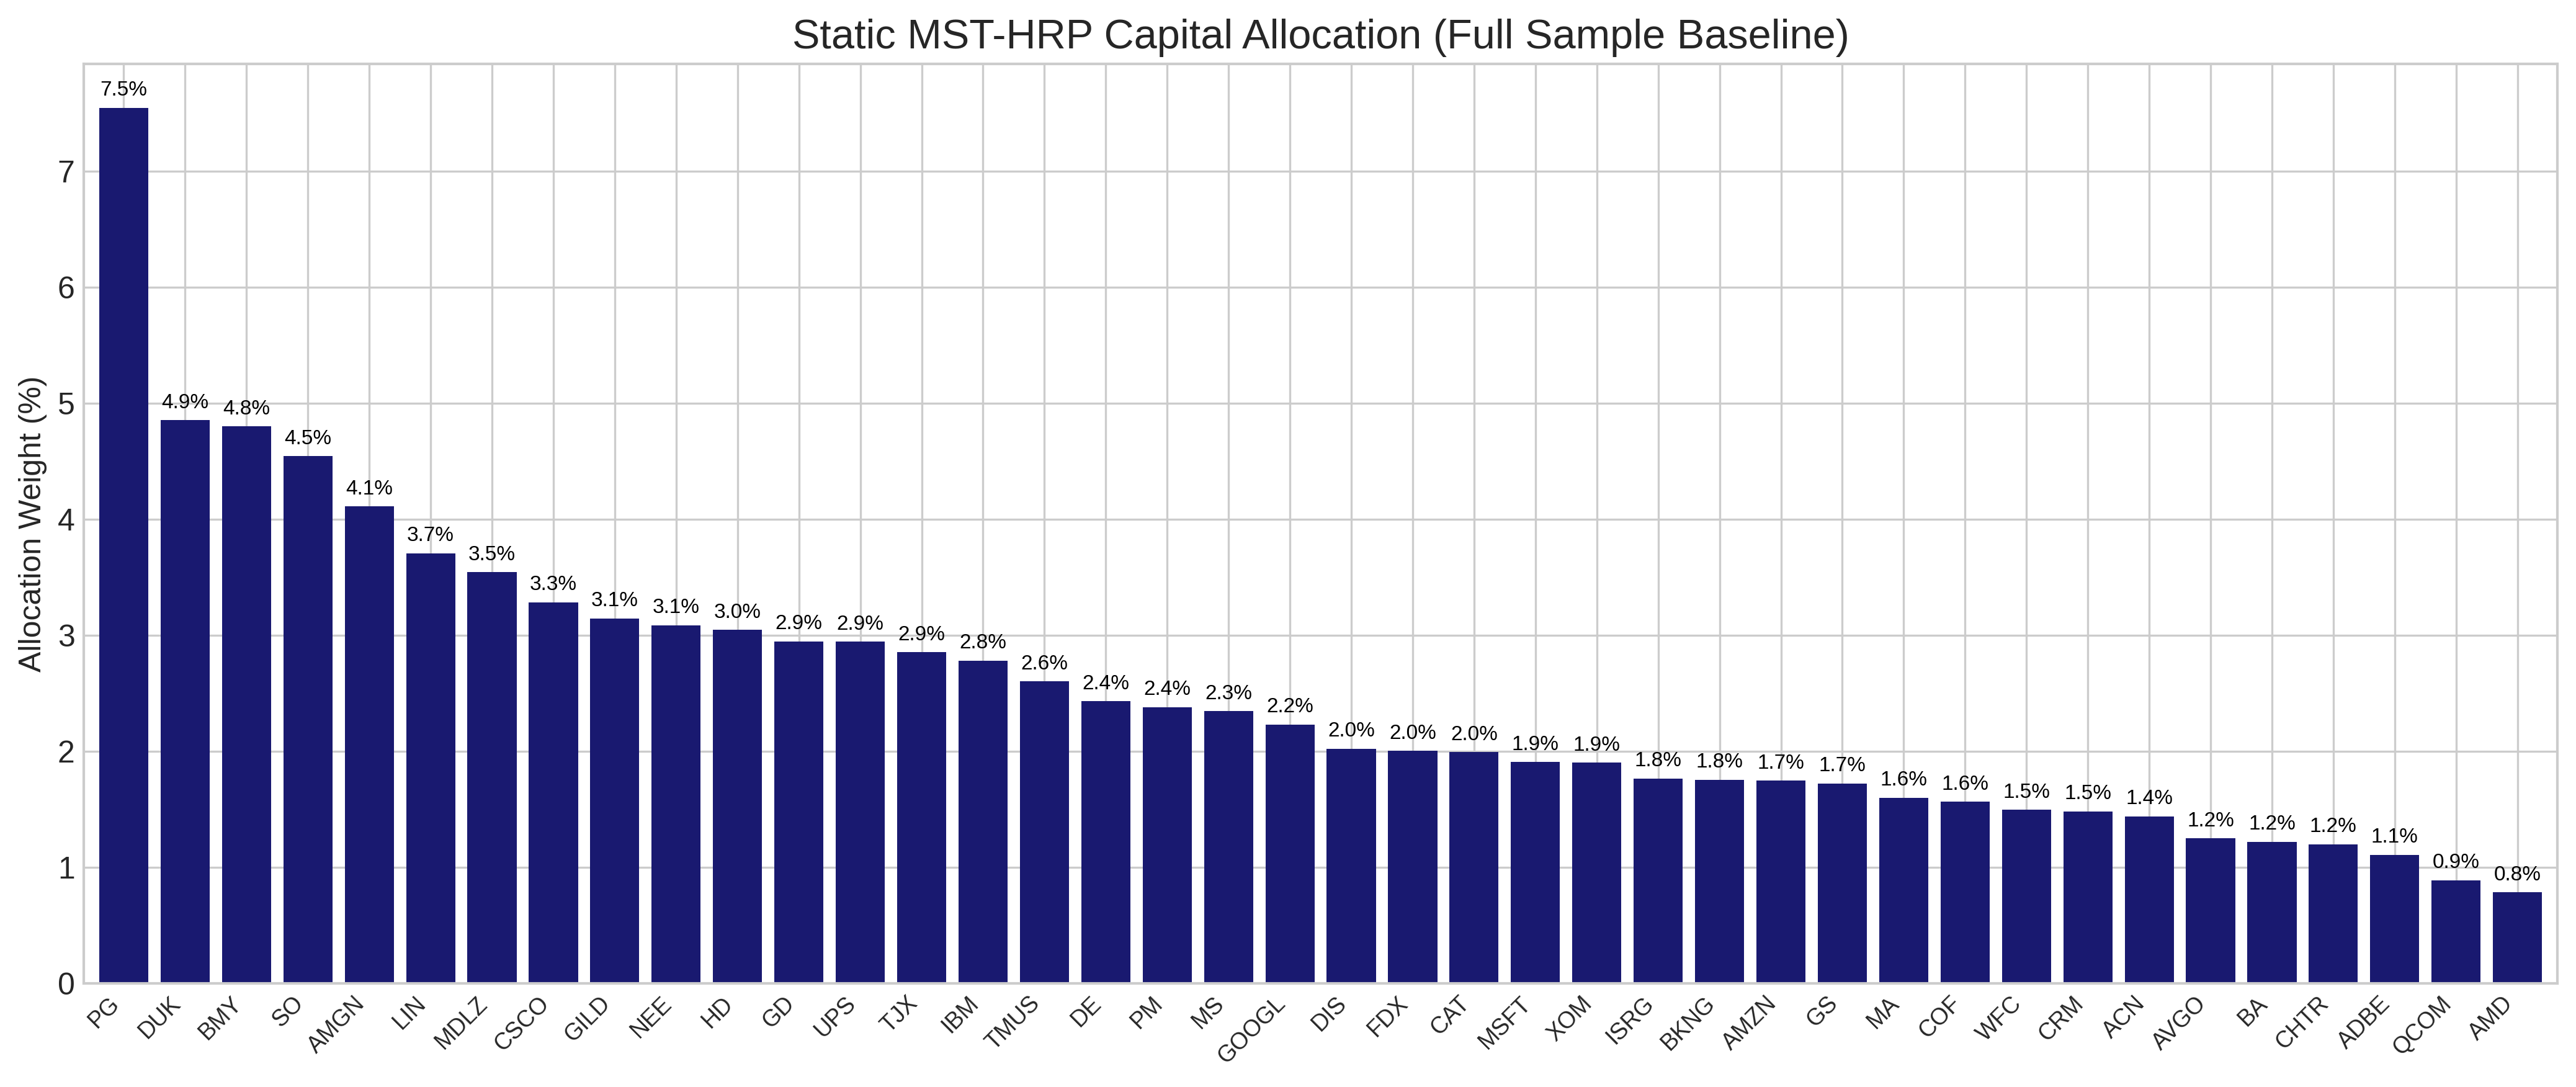

In [25]:
# ==========================================
# CELL 4: RECURSIVE BISECTION (HRP WEIGHTS)
# ==========================================

def get_cluster_var(cov, c_items):
    """Calculates the variance of a cluster based on inverse-variance weights."""
    cov_slice = cov.loc[c_items, c_items]
    inv_diag = 1.0 / np.diag(cov_slice)
    weights = inv_diag / np.sum(inv_diag)
    return np.dot(weights.T, np.dot(cov_slice, weights))

def get_rec_bipart(cov, sort_ix):
    """Computes Hierarchical Risk Parity weights via top-down recursive bisection."""
    weights = pd.Series(1.0, index=sort_ix)
    c_items = [sort_ix]

    while len(c_items) > 0:
        # Bisect clusters
        c_items = [i[j:k] for i in c_items for j, k in ((0, len(i) // 2), (len(i) // 2, len(i))) if len(i) > 1]
        for i in range(0, len(c_items), 2):
            c_items0 = c_items[i]    # Left branch
            c_items1 = c_items[i + 1] # Right branch

            c_var0 = get_cluster_var(cov, c_items0)
            c_var1 = get_cluster_var(cov, c_items1)

            # Allocation factor based on inverse variance of the branches
            alpha = 1.0 - c_var0 / (c_var0 + c_var1)

            weights[c_items0] *= alpha
            weights[c_items1] *= (1 - alpha)

    return weights

# Calculate Full-Sample Static Weights for visualization
mst_hrp_weights = get_rec_bipart(cov_matrix, tickers_sorted)

# --- PITCH VISUALIZATION: ASSET ALLOCATION BAR CHART ---
plt.figure(figsize=(14, 6))
# Sort weights descending for better visual flow
mst_hrp_weights_sorted = (mst_hrp_weights * 100).sort_values(ascending=False)

ax = mst_hrp_weights_sorted.plot(kind='bar', color='midnightblue', width=0.8)
plt.title("Static MST-HRP Capital Allocation (Full Sample Baseline)", fontsize=16)
plt.ylabel("Allocation Weight (%)", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)

# Add value labels on top of the bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=8, color='black', xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

### 5. Backtesting utilizando ventanas móviles y pruebas fuera de la muestra

Utilizar la misma ventana de información para evaluar un modelo presenta graves riesgos como *look-ahead bias*, sobreajustes y poca fiabilidad en producción. Aún más, un solo periodo del tiempo expone el algoritmo a un único escenario de mercado, por lo que sus conclusiones son estáticas y muy poco apropiadas para algo tan dinámico como es la naturaleza del mercado y sus regímenes.

Para evaluar de manera rigurosa el valor de la estrategia propuesta, MST-HRP Topológico, implementamos un anlysis *Walk-Forward* (*Rolling-Window backtest*).

*   **Calibración con la muestra (Entrenamiento):** Observamos una ventana de $T = 252$ dias bursátiles en el pasado (aproximadamente un año). Utilizando únicamente esta ventana histórica, calcualmos la covarianza, extraemos el MST, y generamos los pesos de HRP.
*   **Ejecución fuera de la muestra (Evaluación):** Con los pesos calculados se mantiene el portafolio durante un periodo de rebalanceo de $H = 21$ días bursátiles (aproximadamente un mes) y se calcula el retorno obtenido durante esos 21 días con los retornos diarios reales de la data y los pesos calculados.
*   **Roll Forward:** La ventana se mueve hacia adelante por $H$ días, decartando los datos más viejos, y la topología y asignación de capital se recalcula completamente.

Este método asegura que exista cero *look-ahead bias*. Comparamos la estratégia MST-HRP contra el HRP Estándar (sin filtro) y contra un portafolio de pesos uniformes ($1/N$) para aislar y cuantificar la protección de capital que provee el paso de reducción de ruido topológico.

Starting Walk-Forward Backtest (Lookback: 252d, Rebalance: 21d)...


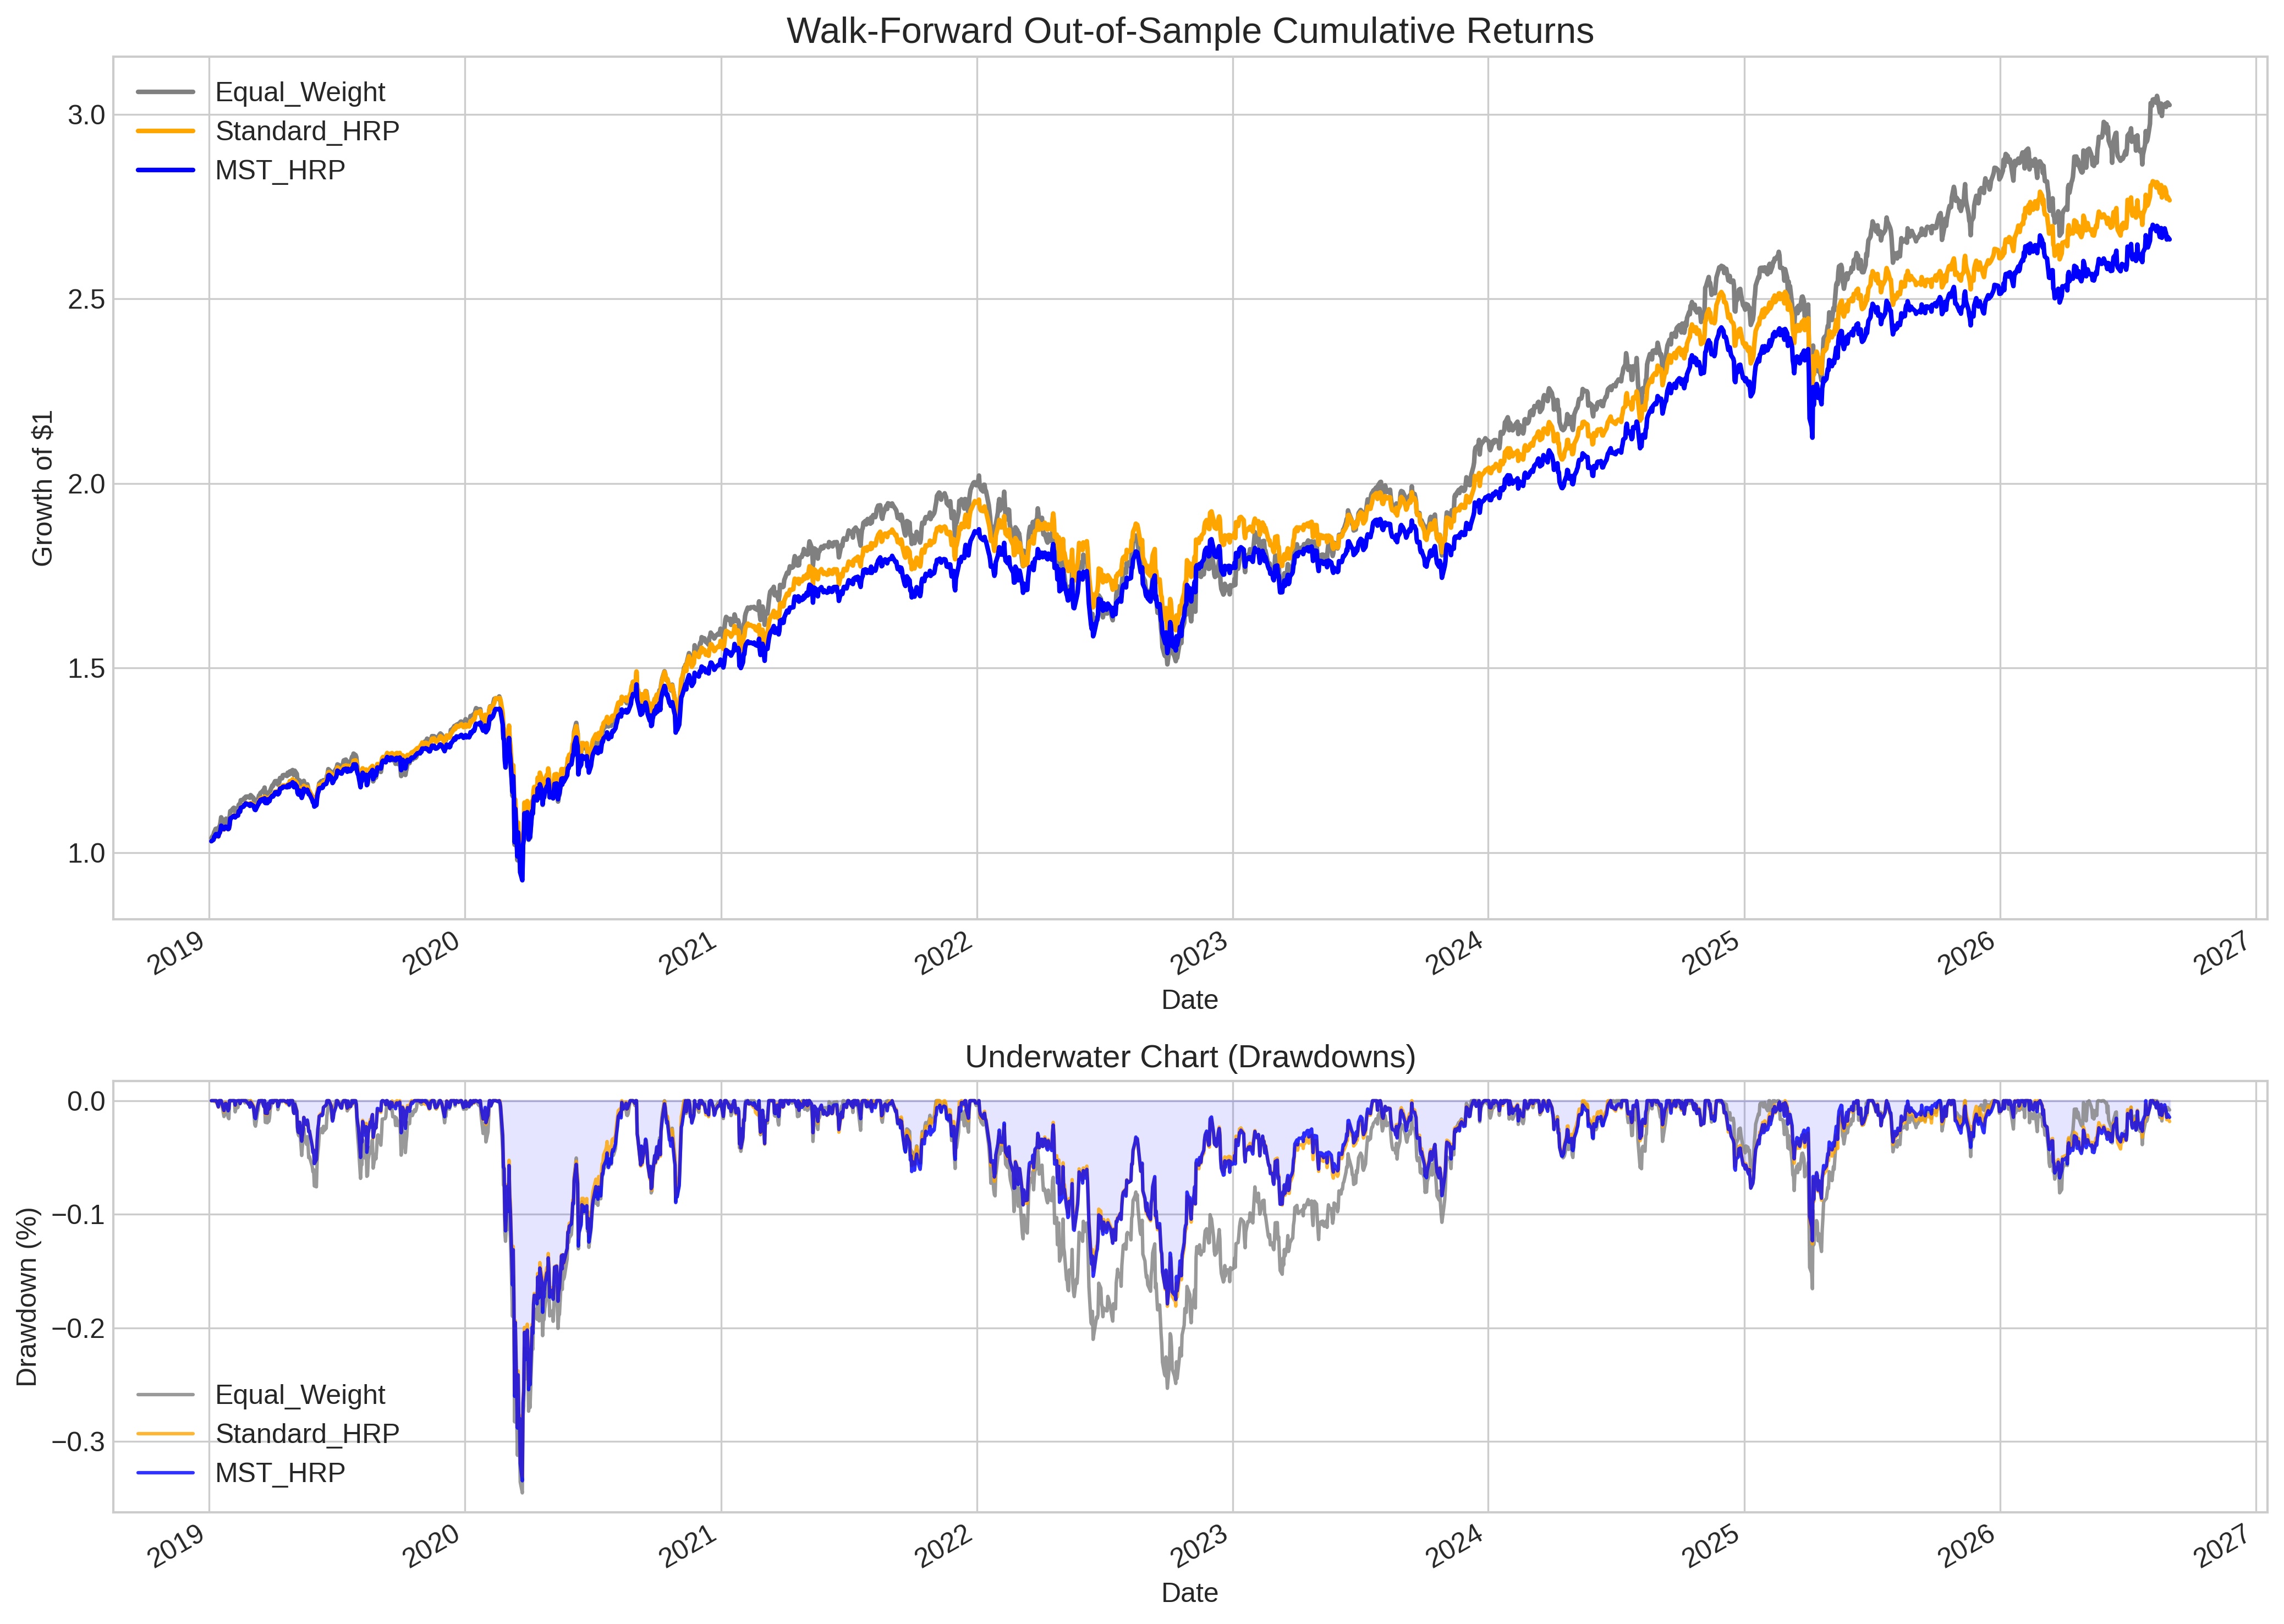


--- Out-of-Sample Performance Metrics ---


,Equal_Weight,Standard_HRP,MST_HRP
Annualized Return,14.50%,13.33%,12.82%
Annualized Volatility,19.34%,17.12%,17.17%
Sharpe Ratio,0.75,0.78,0.75
Max Drawdown,-34.51%,-33.01%,-33.45%


In [26]:
# ==========================================
# CELL 5: WALK-FORWARD OUT-OF-SAMPLE ENGINE
# ==========================================

# 1. Define Backtest Parameters
LOOKBACK_WINDOW = 252 # Train (In-Sample): 1 year of trading days to build the MST/HRP
REBALANCE_FREQ = 21   # Test (Out-of-Sample): Hold weights for 1 month

# Initialize arrays to store the out-of-sample daily returns of our strategies
oos_returns_mst_hrp = pd.Series(dtype=float, index=log_returns.index)
oos_returns_std_hrp = pd.Series(dtype=float, index=log_returns.index)
oos_returns_eq_wt = pd.Series(dtype=float, index=log_returns.index)

# 2. Walk-Forward Loop
# We start at day 252, and step forward by 21 days each loop
print(f"Starting Walk-Forward Backtest (Lookback: {LOOKBACK_WINDOW}d, Rebalance: {REBALANCE_FREQ}d)...")

for start_idx in range(LOOKBACK_WINDOW, len(log_returns), REBALANCE_FREQ):

    # Define Train (In-Sample) and Test (Out-of-Sample) boundaries
    train_start = start_idx - LOOKBACK_WINDOW
    train_end = start_idx
    test_end = min(start_idx + REBALANCE_FREQ, len(log_returns)) # Prevent index out of bounds at the end

    # Slice the data
    train_data = log_returns.iloc[train_start:train_end]
    test_data = log_returns.iloc[train_end:test_end]

    # --- TRAINING PHASE ---
    # 1. Calculate In-Sample Covariance and Correlation
    in_sample_cov = train_data.cov() * 252
    in_sample_corr = train_data.corr()
    tickers = train_data.columns

    # 2. Standard HRP Weights
    raw_dist = compute_distance_matrix(in_sample_corr)
    raw_condensed_dist = squareform(raw_dist, checks=False)
    raw_linkage = linkage(raw_condensed_dist, method='ward')
    raw_sorted_ix = tickers[get_quasi_diag(raw_linkage)]
    std_hrp_w = get_rec_bipart(in_sample_cov, raw_sorted_ix)

    # 3. MST-Filtered HRP Weights
    mst_dist, _ = extract_mst_distances(raw_dist, tickers)
    mst_condensed_dist = squareform(mst_dist, checks=False)
    mst_linkage = linkage(mst_condensed_dist, method='ward')
    mst_sorted_ix = tickers[get_quasi_diag(mst_linkage)]
    mst_hrp_w = get_rec_bipart(in_sample_cov, mst_sorted_ix)

    # 4. Equal Weight Benchmark
    eq_w = pd.Series(1.0 / len(tickers), index=tickers)

    # --- TESTING PHASE ---
    # Dot product of Out-of-Sample daily returns with the static In-Sample weights
    oos_returns_mst_hrp.iloc[train_end:test_end] = test_data.dot(mst_hrp_w)
    oos_returns_std_hrp.iloc[train_end:test_end] = test_data.dot(std_hrp_w)
    oos_returns_eq_wt.iloc[train_end:test_end] = test_data.dot(eq_w)

# Drop the initial lookback period (where we have no out-of-sample trades)
oos_returns_mst_hrp = oos_returns_mst_hrp.dropna()
oos_returns_std_hrp = oos_returns_std_hrp.dropna()
oos_returns_eq_wt = oos_returns_eq_wt.dropna()

# 3. Performance Aggregation
port_returns = pd.DataFrame({
    'Equal_Weight': oos_returns_eq_wt,
    'Standard_HRP': oos_returns_std_hrp,
    'MST_HRP': oos_returns_mst_hrp
})

# Calculate Cumulative Returns & Drawdowns
cum_returns = np.exp(port_returns.cumsum())
rolling_max = cum_returns.cummax()
drawdowns = (cum_returns - rolling_max) / rolling_max

# 4. Visualization (Cumulative Returns and Drawdowns)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

cum_returns.plot(ax=ax1, linewidth=2, color=['gray', 'orange', 'blue'])
ax1.set_title("Walk-Forward Out-of-Sample Cumulative Returns", fontsize=16)
ax1.set_ylabel("Growth of $1")
ax1.legend(loc="upper left")

drawdowns.plot(ax=ax2, linewidth=1.5, alpha=0.8, color=['gray', 'orange', 'blue'])
ax2.fill_between(drawdowns.index, drawdowns['MST_HRP'], 0, color='blue', alpha=0.1)
ax2.set_title("Underwater Chart (Drawdowns)", fontsize=14)
ax2.set_ylabel("Drawdown (%)")
ax2.set_xlabel("Date")

plt.tight_layout()
plt.show()

# 5. Summary Metrics Table
metrics = pd.DataFrame(index=['Annualized Return', 'Annualized Volatility', 'Sharpe Ratio', 'Max Drawdown'])
for col in port_returns.columns:
    ann_ret = port_returns[col].mean() * 252
    ann_vol = port_returns[col].std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol
    mdd = drawdowns[col].min()
    metrics[col] = [f"{ann_ret*100:.2f}%", f"{ann_vol*100:.2f}%", f"{sharpe:.2f}", f"{mdd*100:.2f}%"]

print("\n--- Out-of-Sample Performance Metrics ---")
display(metrics)

### 6. Conclusiones

A partir de los resultados anteriores, notamos lo siguiente:

* Las técnicas jerárquicas de aprendizaje de máquinas son muy efectivas para proteger el cápital y agrupar la volatilidad, ofreciendo mayor estabilidad ajustada por el riesgo al compararlo con una asignación de capital ingenua.
* A pesar de que MST es una herramienta topológica poderosa, su aplicación y eficacia depende fuertemente del contexto. En este caso, se aplicó a un mercado altamente liquido y denso, por lo que la necesidad de reducir el ruido es mucho menor y basta con hacer una asignación con HRP.
* En teoría, esta técnica tendría mejores resultados si se aplicara a mercados con alta dimensionalidad y una gran cantidad de ruido, donde la correlación tradicional falla. Futuras investigaciones deberían aplicar este algoritmo en un mercado bursátil poco liquido o emergente (como la totalidad de la BVC) donde el ruido correlacionado es una fuente primaria de fallas en la optmización.
